# Task 5 — Capstone: Redesign One Chart for the Human Visual System

## 1. Load Data & Build the "BAD EXAMPLE" Chart

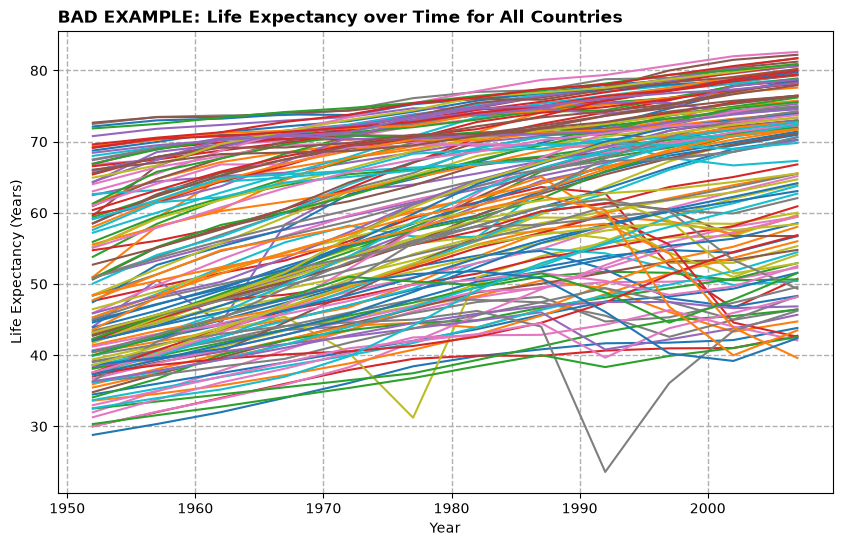

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Gapminder Dataset
# Ensure gapminder.csv is in your working directory
df = pd.read_csv("gapminder.csv")

# 2. Build the Bad Chart (Spaghetti Line Chart of all 142 Countries)
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting every single country with full color saturation creates massive visual clutter
for country in df["country"].unique():
    country_data = df[df["country"] == country]
    ax.plot(
        country_data["year"], country_data["lifeExp"], label=country, linewidth=1.5
    )

# Bad Example Violations: Axis names as title, no clear focus, huge legend, box frame
ax.set_title(
    "BAD EXAMPLE: Life Expectancy over Time for All Countries",
    loc="left",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (Years)")
ax.grid(True, which="both", linestyle="--", linewidth=1)  # Heavy gridlines

# Save raw bad chart
fig.savefig("bad_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Build & Export the Redesigned Chart

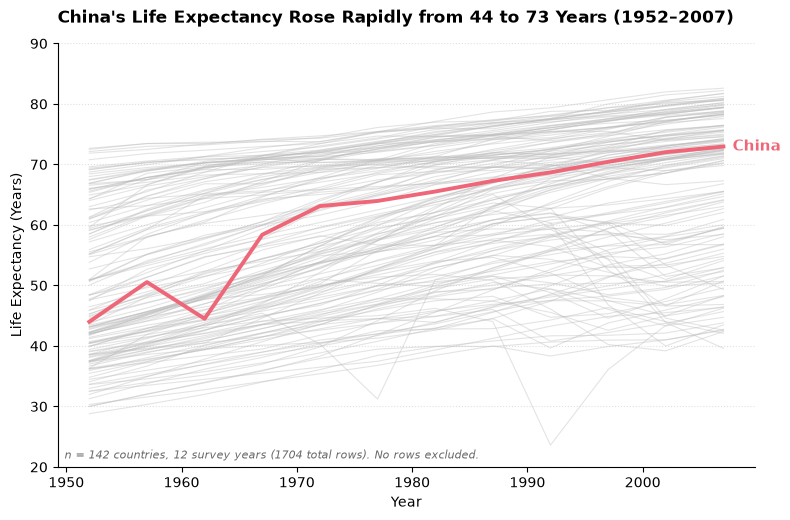

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("gapminder.csv")

# Initialize Object-Oriented Plot API
fig, ax = plt.subplots(figsize=(9, 5.5))

# Separate target country (China) from context countries
target_country = "China"
context_df = df[df["country"] != target_country]
target_df = df[df["country"] == target_country]

# 1. Plot Context in Grey (Reduces extraneous cognitive load)
for country in context_df["country"].unique():
    c_data = context_df[context_df["country"] == country]
    ax.plot(
        c_data["year"],
        c_data["lifeExp"],
        color="#bbbbbb",
        alpha=0.4,
        linewidth=0.8,
    )

# 2. Plot Target in One Strong Pop-out Colour
ax.plot(
    target_df["year"],
    target_df["lifeExp"],
    color="#ee6677",
    linewidth=2.8,
    label="China",
)

# 3. Direct Labeling (Avoids legend lookup memory burden)
last_row = target_df.iloc[-1]
ax.text(
    last_row["year"] + 0.8,
    last_row["lifeExp"],
    "China",
    color="#ee6677",
    fontsize=11,
    fontweight="bold",
    va="center",
)

# 4. Title states the key takeaway finding (not axis names)
ax.set_title(
    "China's Life Expectancy Rose Rapidly from 44 to 73 Years (1952–2007)",
    loc="left",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

# 5. Clear Axes Labels
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Life Expectancy (Years)", fontsize=10)

# 6. Set Y-axis limits & gentle horizontal gridlines for easy ratio comparison
ax.set_ylim(20, 90)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc")

# 7. Declutter Spines (Remove Top & Right Frames to maximize Data-Ink Ratio)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# 8. Declare Sample Size (n) and Exclusions directly on Figure
n_countries = df["country"].nunique()
n_years = df["year"].nunique()
total_rows = len(df)
ax.text(
    0.01,
    0.02,
    f"n = {n_countries} countries, {n_years} survey years ({total_rows} total rows). No rows excluded.",
    transform=ax.transAxes,
    fontsize=8,
    color="#666666",
    style="italic",
)

# Export at 300 DPI with tight bounding box
fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Perception Audit Table (Before vs. After)

### Perception Audit Comparison Table

| Row | Bad Chart (Original) | Redesigned Chart |
| :--- | :--- | :--- |
| **Preattentive** | Hue and position are heavily overloaded; 142 competing colors create visual noise with zero functional pop-out. | Hue (red focus vs. grey context) and Line Thickness instantly draw attention to China in under 250 ms |
| **Pop-out** | No single element pops out. Everything competes for attention, failing to guide the reader. | Exactly one pop-out element (China's bold red line), matching the exact insight claimed in the title. |
| **Gestalt** | Triggers *Continuity* and *Proximity* randomly across 142 crisscrossing lines, creating chaos. | Uses *Continuity* along China's path and *Similarity* (grey grouping for context, red for target). |
| **Cognitive load** | **Extraneous:** Heavy gridlines, box frame, 142 crossing lines. **Intrinsic:** High. **Germane:** Destroyed[cite: 5]. | **Extraneous:** Removed top/right spines, removed vertical gridlines. **Germane:** Protected. |
| **Channels** | Color (Hue) is used for categorical identity across 142 items (ranked worst channel for precise identification). | Position on common 2D scale (highest ranked channel) for trajectory, Hue only for focal contrast. |
| **Working memory** | Forces reader to hold 100+ items in memory trying to match lines (exceeds $4 \pm 1$ chunk limit). | Requires holding only 2 chunks: China (highlighted focus) vs. Rest of World (grey baseline). |

## Human Test Result
### Verbatim Response:
It shows that China's life expectancy grew significantly faster than most other countries from around 44 to over 70 years between 1952 and 2007.
### Does it match the title?
Yes, it matches perfectly. The title claims "China's Life Expectancy Rose Rapidly from 44 to 73 Years (1952–2007)", and the reader immediately extracted both the target entity (China), the timeframe (1952–2007), and the exact scale of increase (from ~44 to ~73 years).  
### Design Evaluation:
No design choices misled the reader. The combination of a strong red line against a faded grey background created an effective preattentive pop-out, allowing the reader to decode the exact message in under 5 seconds without needing a legend.   

## Trade-off / Cost of the Redesign
### What the redesign makes harder to see:
By greying out the context and highlighting only China, this chart makes it extremely difficult to track, identify, or compare individual trajectories of any of the other 141 countries. **For example**, a reader cannot tell which specific country suffered the sharp dip in life expectancy around 1977 or 1992, nor can they compare life expectancy trends between regional neighbors (e.g., India vs. Japan).   
### Why this trade-off was made:
Every design decision has a cost. We deliberately sacrificed country-level comparison across the background data to eliminate extraneous visual noise (cognitive load) and focus 100% of the reader's germane attention on China's historical trend